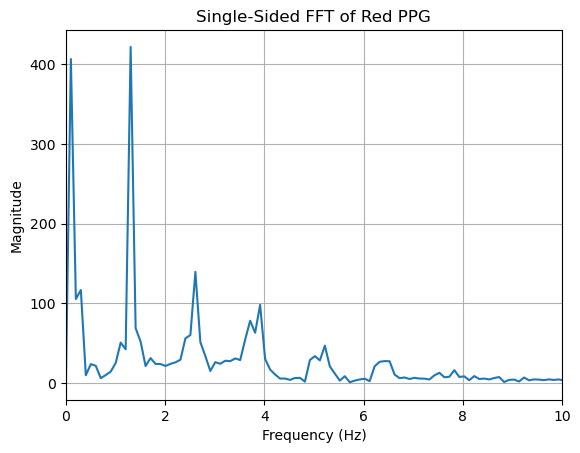

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fs = 25  # sampling frequency

df = pd.read_csv("2.csv")
red_ppg = df.iloc[:, 0].values #, 
red_ppg = red_ppg - np.mean(red_ppg)

N = len(red_ppg)

fft_vals = np.fft.fft(red_ppg)
freq = np.fft.fftfreq(N, d=1/fs)

half_N = N // 2
freq_single = freq[:half_N]
fft_single = fft_vals[:half_N]

magnitude = np.abs(fft_single) / N
magnitude[1:] = 2 * magnitude[1:]

plt.plot(freq_single, magnitude)
plt.xlim(0, 10)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Single-Sided FFT of Red PPG")
plt.grid()
plt.show()


In [11]:
magnitude[:4]

array([3.62336845e-12, 4.06472766e+02, 1.05329514e+02, 1.16586360e+02])

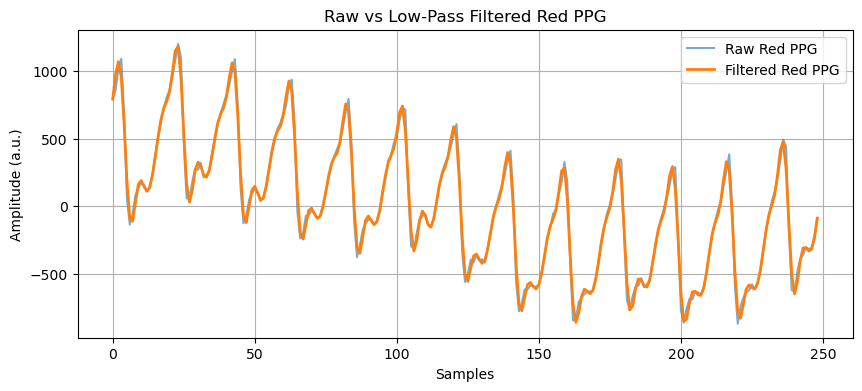

In [ ]:
# Design a filter usinf scipy
from scipy.signal import butter, filtfilt

fs = 25        
cutoff = 5     
order = 4      

def lowpass_filter(signal, cutoff, fs, order=4):
    nyq = 0.5 * fs                 
    normal_cutoff = cutoff / nyq   
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal
red_ppg_filt = lowpass_filter(red_ppg, cutoff, fs)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(red_ppg[:2000], label='Raw Red PPG', alpha=0.6)
plt.plot(red_ppg_filt[:2000], label='Filtered Red PPG', linewidth=2)
plt.xlabel("Samples")
plt.ylabel("Amplitude (a.u.)")
plt.title("Raw vs Low-Pass Filtered Red PPG")
plt.legend()
plt.grid()
plt.show()


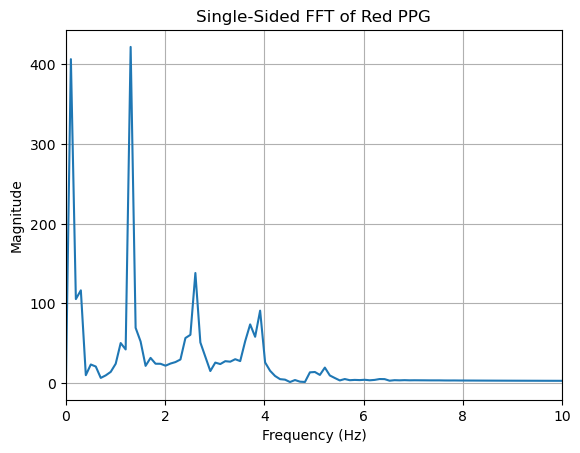

In [17]:
N = len(red_ppg_filt)

fft_vals = np.fft.fft(red_ppg_filt)
freq = np.fft.fftfreq(N, d=1/fs)

half_N = N // 2
freq_single = freq[:half_N]
fft_single = fft_vals[:half_N]

magnitude = np.abs(fft_single) / N
magnitude[1:] = 2 * magnitude[1:]

plt.plot(freq_single, magnitude)
plt.xlim(0, 10)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Single-Sided FFT of Red PPG")
plt.grid()
plt.show()

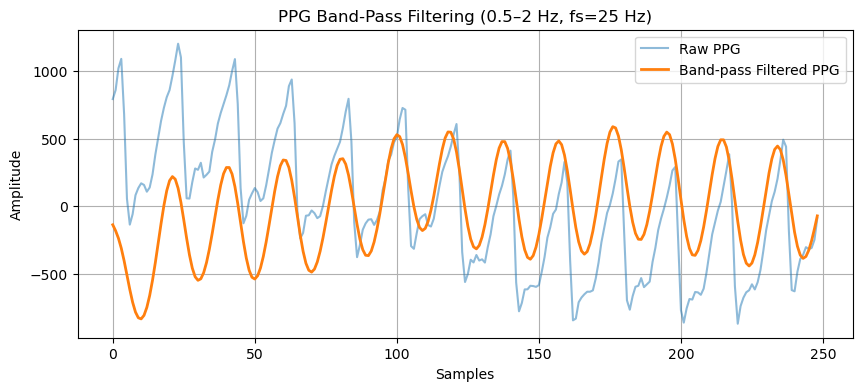

In [21]:
# Design a bandpass filter
from scipy.signal import butter, filtfilt

def bandpass_filter(signal, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq

    b, a = butter(order, [low, high], btype='band')
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal
# Apply the filter
ppg_band = bandpass_filter(red_ppg, 0.05, 2.0, fs)

# plot in time domian
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(red_ppg[:300], label='Raw PPG', alpha=0.5)
plt.plot(ppg_band[:300], label='Band-pass Filtered PPG', linewidth=2)
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.title("PPG Band-Pass Filtering (0.5–2 Hz, fs=25 Hz)")
plt.legend()
plt.grid()
plt.show()
